## DSC 612: DEEP LEARNING & NEURAL NETWORKS
### Assignment on building CNN Architecture for Medical Images Classification 



*Submitted by:* \
Saksham Chauhan \
2025MCS110001 \
M.Tech. in Artificial Intelligence & Data Science


### Dataset Used: Pneumonia Detection from Chest X-Rays
The dataset is an augmented and partitioned version of paultimothymooney's chest-xray-pneumonia dataset, with the images divided into 10% test, 10% validation, and 80% train folders. These steps were taken to create a more balanced dataset. In its augmented form, the test folder contains 400 PNEUMONIA and 400 NORMAL images; the validation folder contains 400 PNEUMONIA and 400 NORMAL images; and the training folder contains 4000 PNEUMONIA and 4000 NORMAL images.

path = kagglehub.dataset_download("umitka/chest-x-ray-balanced")

### 1. Importing libraries and loading data

In [7]:
## Adding the dataset path and attaching the dataset 

import os
base_path = '/kaggle/input/datasets/umitka/chest-x-ray-balanced/chest_xray_balanced'

In [18]:
## Importing required libraries

import pandas as pd
import numpy as np

## tensorflow libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout, MaxPooling2D, GlobalAveragePooling2D, Activation, BatchNormalization, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

### 2. Creating Image Generators and Enabling Data Augmentation

**Dataset Preprocessing** \
The dataset preprocessing steps include creating data generators and enabling data augmentation steps such as:
1. Rescaling the images
2. Shearing the images
3. Zooming the images
4. Rotating the images
5. Shifting the images wrt height and width

These data augmentation steps would help in generalising the model well and improve the model performance.

In [39]:
## Parameters: Image size and Batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

## Creating Data Generators: Train, Validation and Test
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.1,
    zoom_range=0.1,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
)
# Data Augmentation techniques used: Rescaling, Shear, Zoom, Rotating, Shifting  

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

## Reading the data with data generators
train_data = train_datagen.flow_from_directory(
    directory=os.path.join(base_path, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
)

val_data = val_datagen.flow_from_directory(
    directory=os.path.join(base_path, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
)

test_data = test_datagen.flow_from_directory(
    directory=os.path.join(base_path, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 8000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


In [20]:
## Printing data shape and labels
images, labels = next(train_data)
print("Shape of the images ", images.shape)  # batchsize, pixel x pixel, #channels

Shape of the images  (32, 224, 224, 3)


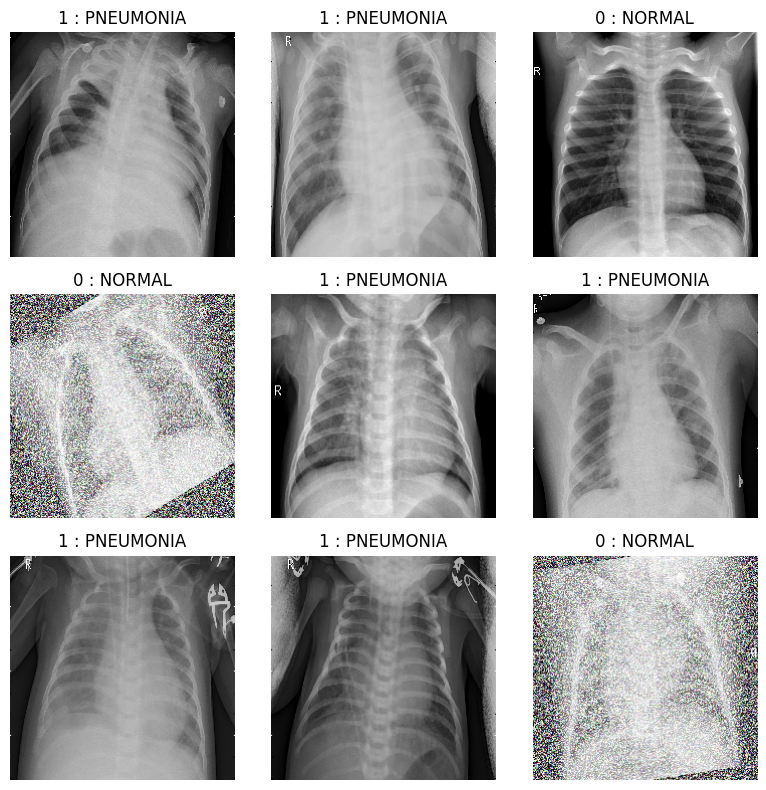

In [38]:
# Displaying sample of data
images, labels = next(train_data)
class_indices = train_data.class_indices

idx_to_class = {v: k for k, v in class_indices.items()}

# Plot 3x3 grid
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    
    label_int = int(labels[i])
    label_name = idx_to_class[label_int]
    
    plt.title(f"{label_int} : {label_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 3. Creating custom CNN Architecture

**Detailed Explanation of the Model Architecture** \
The CNN architecture proposed below has 3 blocks with 2 Convolution Layers each followed by a Batch Normalisation and Max Pooling Layer to halve the feature map space. All convolution layers have ReLu as the activation function.


> Block 1 
- Conv 1: 16 filters of size 3x3 with HeNormal initialiser
- Conv 2: 32 filters of size 3x3
- Batch Normalisation
- Max Pooling Layer

> Block 2
- Conv 1: 64 filters of size 3x3 
- Conv 2: 128 filters of size 3x3
- Batch Normalisation
- Max Pooling Layer

> Block 3
- Conv 1: 256 filters of size 3x3 with L2 regularisation
- Dropout of 0.3
- Conv 2: 512 filters of size 3x3 with L2 regularisation
- Dropout of 0.4
- Batch Normalisation
- Max Pooling Layer

> Block 4
- Global Average Pooling Layer to flatten
- Dense layer with 256 neurons with ReLu activation function
- Dropout of 0.6
- Dense layer with 128 neurons with ReLu activation function
- Dropout of 0.3
- Dense layer with 1 neuron and sigmoid activation function for binary classification

As is the standard practice, the number of filters double with each convolution layer and weak dropouts are introduced in convolutional layers with large number of filters to avoid overfitting and capturing noise from the training data. Further dropouts are introduced in the dense layers to avoid overfitting. 

In [22]:
## creating a user defined function to generate a custom CNN model

def create_custom_cnn(input_shape):

    model = Sequential()
    model.add(Input(shape=input_shape)) ## adding an input layer

    # Block 1
    model.add(Conv2D(16, kernel_size = (3,3), strides = (1,1), padding = 'same',kernel_initializer=HeNormal(), bias_initializer='zeros', activation='relu')) 
    model.add(Conv2D(32, kernel_size = (3,3), strides = (1,1), padding = 'same', activation='relu'))
    model.add(BatchNormalization())

    model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))  

    # Block 2
    model.add(Conv2D(64, kernel_size = (3,3), strides = (1,1), padding = 'same', activation='relu'))
    model.add(Conv2D(128, kernel_size = (3,3), strides = (1,1), padding = 'same', activation='relu'))
    model.add(BatchNormalization())
    
    model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))  


    # Block 3
    model.add(Conv2D(256, kernel_size = (3,3), strides = (1,1), padding = 'same', activation = 'relu', kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.3))
    model.add(Conv2D(512, kernel_size = (3,3), strides = (1,1), padding = 'same', activation = 'relu', kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.4))
    model.add(BatchNormalization())
    
    model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))  ## halves the feature map space

    
    # Flatten + Dense
    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.6))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    return(model)

In [23]:
## Define the model input shape of the images
input_shape = (224, 224, 3)

## Create the custom model
model = create_custom_cnn(input_shape)

## Display model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 224, 224, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 56, 56, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 56, 56, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 56, 56, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,739,809 (6.64 MB)

 Trainable params: 1,738,465 (6.63 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [24]:
## Compiling the model
model.compile(
    loss = 'binary_crossentropy', # binary cross entropy 
    optimizer = Adam(learning_rate=1e-4),  ## very small learning rate is useful for medical images
    metrics = ['accuracy']) # Using accuracy 

## Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,                 
    restore_best_weights=True
)

# LR scheduler
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)

# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 236s 909ms/step - accuracy: 0.8137 - loss: 0.4559 - val_accuracy: 0.5000 - val_loss: 1.8015 - learning_rate: 1.0000e-04
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 229s 914ms/step - accuracy: 0.8555 - loss: 0.3133 - val_accuracy: 0.5487 - val_loss: 0.5956 - learning_rate: 1.0000e-04
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 230s 919ms/step - accuracy: 0.8688 - loss: 0.2955 - val_accuracy: 0.6125 - val_loss: 0.7537 - learning_rate: 1.0000e-04
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 229s 914ms/step - accuracy: 0.8864 - loss: 0.2593 - val_accuracy: 0.9287 - val_loss: 0.4979 - learning_rate: 1.0000e-04
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 228s 913ms/step - accuracy: 0.9112 - loss: 0.2446 - val_accuracy: 0.6150 - val_loss: 0.6283 - learning_rate: 1.0000e-04
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 233s 932ms/step - accuracy: 0.9245 - loss: 0.2243 - val_accuracy: 0.9450 - val_loss: 0.3393 - learning_rate: 1.0000e-04
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Find best epoch (lowest validation loss)
best_epoch = np.argmin(history.history['val_loss'])

# Extract accuracies
train_acc = history.history['accuracy'][best_epoch]
val_acc = history.history['val_accuracy'][best_epoch]

print(f"Best Epoch: {best_epoch + 1}")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

### 4. Evaluating Model Performance

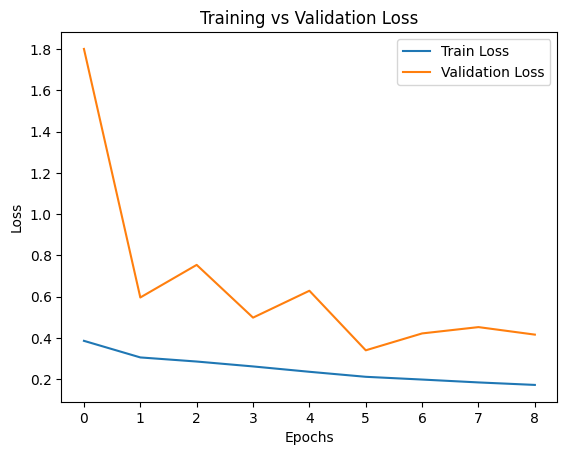

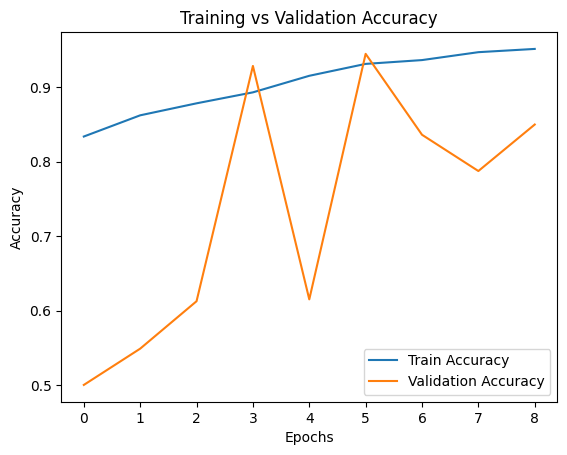

In [26]:
## Displaying the plots of model loss and accuracy

# Plot Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

In [27]:
## Displaying the Classification report

test_data.reset()

y_pred = model.predict(test_data)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()

y_true = test_data.classes
print(classification_report(y_true, y_pred_classes))
print(confusion_matrix(y_true, y_pred_classes))

25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 683ms/step
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       400
           1       0.93      0.92      0.93       400

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800

[[373  27]
 [ 31 369]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step


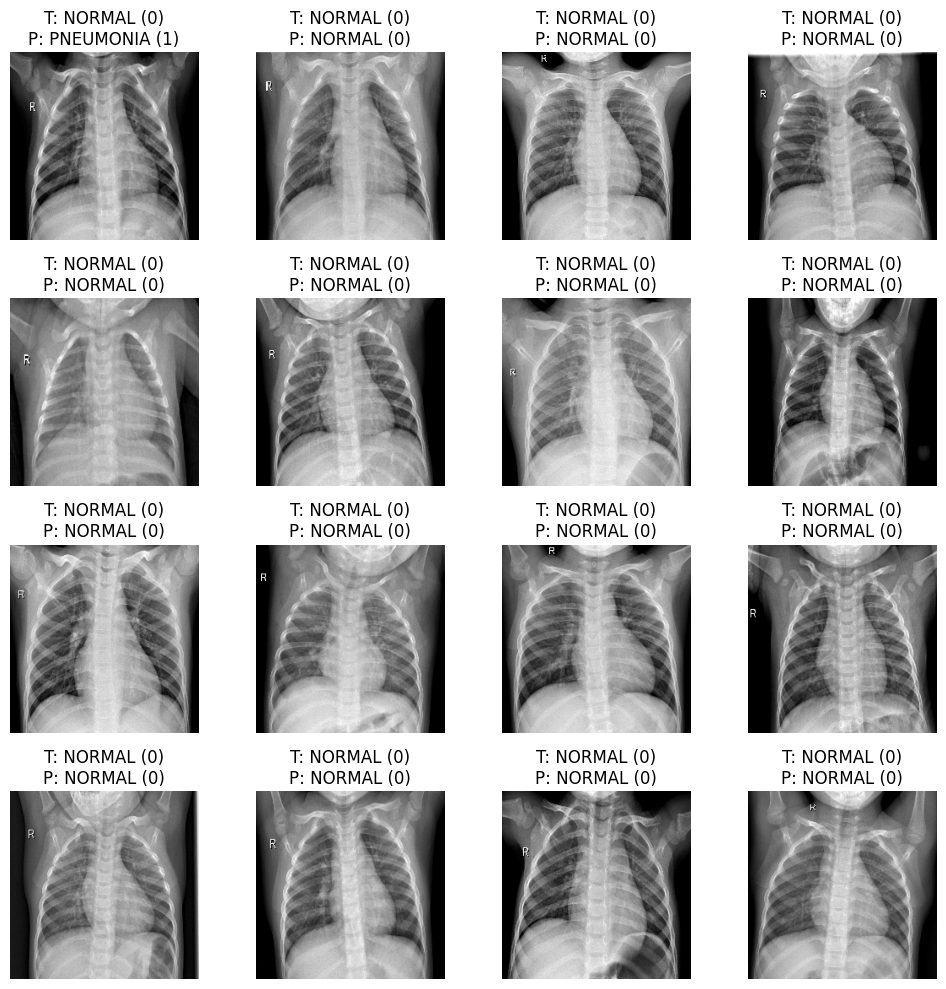

In [28]:
## Generating Predicting vs Actual Labels for Test data 
images, labels = next(test_data)

pred_probs = model.predict(images)
pred_labels = (pred_probs > 0.5).astype(int).reshape(-1)

# Class mapping
class_indices = test_data.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

# Plot 4x4 grid
plt.figure(figsize=(10, 10))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i])
    
    true_label = int(labels[i])
    pred_label = int(pred_labels[i])
    
    true_name = idx_to_class[true_label]
    pred_name = idx_to_class[pred_label]
    
    plt.title(f"T: {true_name} ({true_label})\nP: {pred_name} ({pred_label})")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 5. Model Improvement Techniques
1. **Dropouts**: Dropouts are introduced in Convolution layers with large number of filters and dense layers to avoid overfitting.
2. **Data Augmentation**: Datasrt is augmented with different operations on images such as rotations, shears, zoom, etc. for model to generalise well beyond the scope of training dataset. 
3. **Batch Normalisation**: The outputs of the block of convolution layers is normalised before entering the max pooling layers for speeding up the computation process.
4. **L2 Regularisation**: The higher weights are penalised especially in convolution layers with large number of filters
5. **Early Stopping**: To avoid overfitting, callbacks stop training when validation performance stops improving.
6. **Learning Rate Scheduler**: The scheduler dynamically adjusts the learning rate over time to improve training efficiency and convergence speed.
7. **Weight Initialisation**: To set the starting weights of a neural network to ensure stable gradients and effective training.